In [19]:
from rocketpy import Environment, Flight, Rocket, SolidMotor
import numpy
import datetime
import pandas as pd
import numpy as np

In [20]:
%config InlineBackend.figure_formats = ['svg']
%matplotlib inline

In [21]:
env = Environment(latitude=-21.9430528, longitude=-48.9540861, elevation=478)
tomorrow = datetime.date.today() + datetime.timedelta(days=1)
env.set_date((tomorrow.year, tomorrow.month, tomorrow.day, 12))
# GFS  Global Forecast System
env.set_atmospheric_model(type="Forecast", file="GFS")


Gravity Details

Acceleration of gravity at surface level:    9.7861 m/s²
Acceleration of gravity at  78.972 km (ASL): 9.5482 m/s²


Launch Site Details

Launch Date: 2026-07-15 12:00:00 UTC
Launch Site Latitude: -21.94305°
Launch Site Longitude: -48.95409°
Reference Datum: SIRGAS2000
Launch Site UTM coordinates: 91457.82 W    7568202.63 S
Launch Site UTM zone: 23K
Launch Site Surface Elevation: 475.6 m


Atmospheric Model Details

Atmospheric Model Type: Forecast
Forecast Maximum Height: 78.972 km
Forecast Time Period: from 2026-07-07 03:00:00 to 2026-07-30 06:00:00 utc
Forecast Hour Interval: 3 hrs
Forecast Latitude Range: From 90.0° to -90.0°
Forecast Longitude Range: From 0.0° to 359.75°

Surface Atmospheric Conditions

Surface Wind Speed: 5.48 m/s
Surface Wind Direction: 116.12°
Surface Wind Heading: 296.12°
Surface Pressure: 96445.30 hPa
Surface Temperature: 284.63 K
Surface Air Density: 118.047 kg/m³
Surface Speed of Sound: 338.21 m/s


Earth Model Details

Earth Radius at Laun

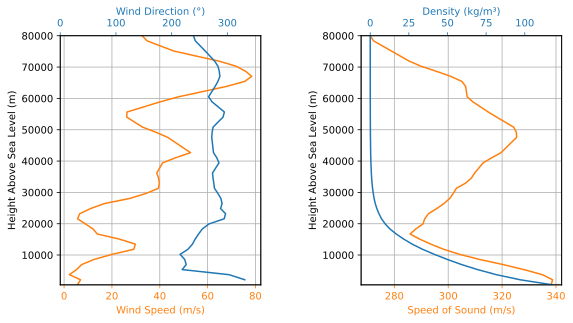

In [22]:
env.info()

In [23]:
# motor

motor_data = pd.read_csv("motor.csv")

In [24]:
print("DataFrame columns:", motor_data.columns)
if 'Unnamed: 0' in motor_data.columns:
    motor_data = motor_data.drop(columns=['Unnamed: 0'])
    print("Dropped 'Unnamed: 0' column.")
    print("Updated DataFrame columns:", motor_data.columns)

# Check for duplicate time values in the first column and remove them
if motor_data.iloc[:, 0].duplicated().any():
    print("Duplicate time values found in the thrust curve data. Removing duplicates.")
    motor_data = motor_data.drop_duplicates(subset=[motor_data.columns[0]])


# Select only the 'Time(s)' and 'Thrust(N)' columns and get the values as a NumPy array
thrust_source_array = motor_data[['Time(s)', 'Thrust(N)']].values


# Now, use the NumPy array as the thrust source to initialize SolidMotor
Dedalo_motor = SolidMotor(
    thrust_source=thrust_source_array, # Use the NumPy array
    dry_mass= 1.86,
    dry_inertia=(0.04718349, 0.04718349, 0.00178498),
    nozzle_radius=20.715,
    grain_number=3,
    grain_density=1750,
    grain_outer_radius=0.0315,
    grain_initial_inner_radius=0.010,
    grain_initial_height=0.116,
    grain_separation=0,
    grains_center_of_mass_position=0.174, 
    center_of_dry_mass_position=0.24,
    nozzle_position=0,
    burn_time=motor_data['Time(s)'].iloc[-1],
    throat_radius=0.0070,
    coordinate_system_orientation="nozzle_to_combustion_chamber",
)

print("\nSolidMotor initialized successfully!")

DataFrame columns: Index(['Time(s)', 'Thrust(N)'], dtype='str')

SolidMotor initialized successfully!
